# H1 — Space Control and Value
## Adapted for seasonal aggregated data (Wyscout / `wyscout_sample.csv`)

**Original hypothesis.** A spatial-tactical scouting platform built on StatsBomb 360° freeze frames, reducing each player's game to four composite indices: **PROGRESSION** (forward play volume), **DANGEROUSNESS** (threat creation), **RECEPTION** (play between lines and in tight spaces), and **GRAVITY** (how much the player pulls the opponent defense), all compared within the same macro role.

### Why this is an adaptation, not a recreation

The original pipeline calculates, for each pass with a 360° freeze frame, the position of every visible opponent and constructs the **convex hull** of the defensive block — measuring whether a player is "between lines", whether a pass "penetrates" the block, and how much opponents compress around the ball carrier (**Gravity**). None of this exists in `wyscout_sample.csv`, which is a season-aggregated export (1,059 outfield players) without opponent coordinates or individual event trajectories.

Instead, the four indices here are computed as a **composite percentile of real Wyscout columns**, evaluated within the same macro role — following the same percentile-within-role philosophy as the original, applied to statistical proxies rather than freeze-frame geometry:

| Original Index (H1, StatsBomb 360°) | Adaptation Here (Wyscout aggregated) |
|---|---|
| PROGRESSION — line-breaking passes (geometry + EPV) | mean percentile of `Progressive passes/90`, `Progressive runs/90`, `Passes to final third/90` |
| DANGEROUSNESS — total EPV generated in possession | mean percentile of `Expected goals/90`, `Expected assists/90` |
| RECEPTION — % touches between lines, exits under pressure | mean percentile of `Touches in box/90`, `Received passes/90`, `Deep completions/90` |
| GRAVITY — measured displacement of opponent centroid | mean percentile of `Fouls suffered/90`, `Offensive duels/90` |

**Notice on GRAVITY — the weakest proxy of the four.** The original index measures, using true opponent coordinates, how much the defensive block compresses around the player. Here, no column measures this directly; `Fouls suffered/90` and `Offensive duels/90` serve as an indirect proxy — based on the rationale that a player who frequently draws duels and wins fouls commands extra defensive attention — but it is an inference, not a physical measurement. Treat GRAVITY as directional, just as the original notebook already flagged Gravity as experimental even with tracking data.

## Section 0 — Setup

In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

pd.set_option("display.max_columns", 12)

def _find_data_path() -> Path:
    env_path = os.getenv('DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)
    cur = Path.cwd()
    for _ in range(6):
        for candidate in [
            cur / "webapp" / "backend" / "data" / "wyscout_sample.csv",
            cur / "data" / "wyscout_sample.csv",
        ]:
            if candidate.exists():
                return candidate
        if cur.parent == cur:
            break
        cur = cur.parent
    candidates = [
        Path('../../webapp/backend/data/wyscout_sample.csv'),
        Path('../webapp/backend/data/wyscout_sample.csv'),
        Path('webapp/backend/data/wyscout_sample.csv'),
        Path('../../data/wyscout_sample.csv'),
        Path('../data/wyscout_sample.csv'),
        Path('data/wyscout_sample.csv'),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Could not locate wyscout_sample.csv. Please set DATA_PATH environment variable.")

DATA_PATH = _find_data_path()
MIN_MINUTES = 300

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = [str(c).strip() for c in df.columns]

MACRO_MAP = {
    "GK": "GK", "CB": "CB", "LCB": "CB", "RCB": "CB",
    "LB": "FB", "RB": "FB", "LWB": "FB", "RWB": "FB",
    "DMF": "MID", "LDMF": "MID", "RDMF": "MID", "CMF": "MID", "LCMF": "MID", "RCMF": "MID",
    "AMF": "CAM",
    "LAMF": "WIDE", "RAMF": "WIDE", "LW": "WIDE", "RW": "WIDE", "LWF": "WIDE", "RWF": "WIDE",
    "CF": "FW", "SS": "FW",
}
MACRO_LABEL_EN = {"CB": "Center Back", "FB": "Full Back", "MID": "Midfielder",
                   "CAM": "Attacking Midfielder", "WIDE": "Winger", "FW": "Forward"}
ROLE_ORDER = ["CB", "FB", "MID", "CAM", "WIDE", "FW"]
ROLE_COLORS = {"CB": "#1f77b4", "FB": "#ff7f0e", "MID": "#2ca02c",
               "CAM": "#9467bd", "WIDE": "#d62728", "FW": "#8c564b"}

df["primary_position"] = df["Position"].apply(lambda p: str(p).split(",")[0].strip())
df["macro_pos"] = df["primary_position"].map(MACRO_MAP).fillna("MID")
df["minutes"] = df["Minutes played"]

out = df[(df["macro_pos"] != "GK") & (df["minutes"] >= MIN_MINUTES)].copy()
print(f"Pool: {len(out)} outfield players (>= {MIN_MINUTES} min)")
print(out["macro_pos"].value_counts().reindex(ROLE_ORDER))


Pool: 1059 outfield players (>= 300 min)
macro_pos
CB      217
FB      212
MID     227
CAM      75
WIDE    183
FW      145
Name: count, dtype: int64


C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_13368\3346293422.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["primary_position"] = df["Position"].apply(lambda p: str(p).split(",")[0].strip())
C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_13368\3346293422.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["macro_pos"] = df["primary_position"].map(MACRO_MAP).fillna("MID")
C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_13368\3346293422.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

## Section 1 — Construction of the 4 Indices

In [2]:
IDX_COLS = {
    "PROGRESSION":   ["Progressive passes/90", "Progressive runs/90", "Passes to final third/90"],
    "DANGEROUSNESS": ["Expected goals/90", "Expected assists/90"],
    "RECEPTION":     ["Touches in box/90", "Received passes/90", "Deep completions/90"],
    "GRAVITY":       ["Fouls suffered/90", "Offensive duels/90"],
}
IDX_LABEL_EN = {
    "PROGRESSION": "Progression", "DANGEROUSNESS": "Dangerousness",
    "RECEPTION": "Reception", "GRAVITY": "Gravity"
}

new_cols = {}
for name, cols in IDX_COLS.items():
    for c in cols:
        pc = f"pct__{c}"
        if pc not in out.columns and pc not in new_cols:
            new_cols[pc] = out.groupby("macro_pos")[c].rank(pct=True) * 100

for k, v in new_cols.items():
    out[k] = v

for name, cols in IDX_COLS.items():
    out[f"idx__{name}"] = out[[f"pct__{c}" for c in cols]].mean(axis=1)

out = out.copy()
out[[f"idx__{k}" for k in IDX_COLS]].describe().round(1)


,idx__PROGRESSION,idx__DANGEROUSNESS,idx__RECEPTION,idx__GRAVITY
count,1059.0,1059.0,1059.0,1059.0
mean,50.3,50.3,50.3,50.3
std,22.3,21.7,19.6,25.3
min,1.6,3.1,3.1,0.7
25%,33.6,34.8,34.7,30.5
50%,50.2,49.7,50.0,49.9
75%,67.1,66.0,64.7,70.5
max,99.3,99.1,98.9,100.0


## Section 2 — Construct Validity

**Cronbach's Alpha** by macro role (target ≥ 0.6 for a cohesive construct, ≥ 0.4 acceptable for a multifaceted construct — same thresholds as the original notebook) and **cross-correlation** between the four indices (target |r| < 0.6, confirming they are non-redundant).

In [3]:
def cronbach_alpha(item_df: pd.DataFrame) -> float:
    item_df = item_df.dropna()
    k = item_df.shape[1]
    if k < 2 or len(item_df) < 3:
        return np.nan
    item_vars = item_df.var(axis=0, ddof=1)
    total_var = item_df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)


alpha_rows = []
for name, cols in IDX_COLS.items():
    pct_cols = [f"pct__{c}" for c in cols]
    row = {"Index": IDX_LABEL_EN[name]}
    role_alphas = []
    for role in ROLE_ORDER:
        a = cronbach_alpha(out.loc[out["macro_pos"] == role, pct_cols])
        row[role] = round(a, 2) if pd.notna(a) else None
        if pd.notna(a):
            role_alphas.append(a)
    row["mean"] = round(np.mean(role_alphas), 2) if role_alphas else None
    alpha_rows.append(row)
pd.DataFrame(alpha_rows).set_index("Index")

,CB,FB,MID,CAM,WIDE,FW,mean
Index,,,,,,,
Progression,0.82,0.64,0.65,0.49,0.42,0.75,0.63
Dangerousness,0.24,0.18,0.42,0.50,0.18,0.10,0.27
Reception,0.35,0.34,0.48,0.23,0.47,0.52,0.40
Gravity,0.64,0.75,0.81,0.63,0.67,0.60,0.68


In [4]:
idx_cols = [f"idx__{k}" for k in IDX_COLS]
cross_corr = out[idx_cols].corr(method="spearman")
cross_corr.columns = cross_corr.index = [IDX_LABEL_EN[c.replace("idx__", "")] for c in cross_corr.columns]
cross_corr.round(2)

,Progression,Dangerousness,Reception,Gravity
Progression,1.00,0.14,0.49,0.11
Dangerousness,0.14,1.00,0.53,0.10
Reception,0.49,0.53,1.00,0.10
Gravity,0.11,0.10,0.10,1.00


All four indices remain below the redundancy threshold (|ρ| < 0.6 in all pairs), confirming that no two indices measure essentially the same construct — even with Reception and Dangerousness nearing the limit, which is expected: a player receiving passes near the box also tends to be in position to generate xG/xA.

## Section 3 — Leaderboard and Individual Profile

Highest average of the 4 indices: Nathan Brecken (Team 52, FW)


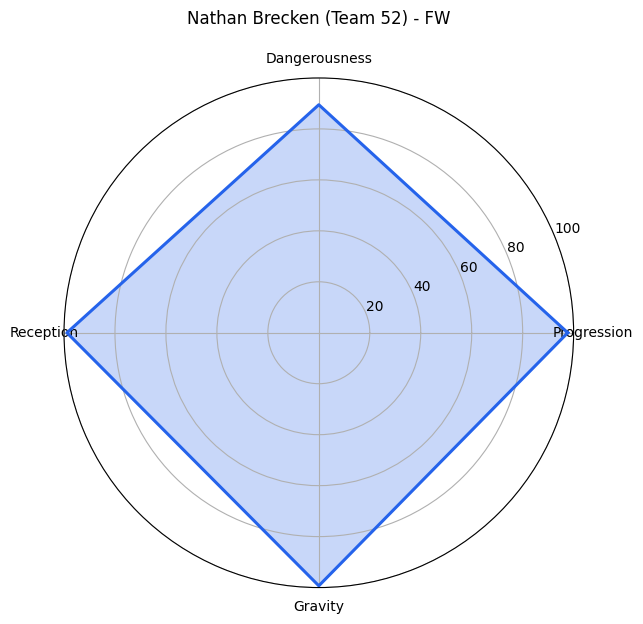

In [5]:
def build_radar(row: pd.Series, height=6.5):
    labs = [IDX_LABEL_EN[k] for k in IDX_COLS]
    vals = [float(row[f"idx__{k}"]) for k in IDX_COLS]
    angles = np.linspace(0, 2 * np.pi, len(labs), endpoint=False).tolist()
    vals += vals[:1]; angles += angles[:1]
    fig, ax = plt.subplots(figsize=(height, height), subplot_kw=dict(polar=True))
    ax.plot(angles, vals, color="#2563eb", linewidth=2.2)
    ax.fill(angles, vals, color="#2563eb", alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labs)
    ax.set_ylim(0, 100)
    p_name = row["Player"]
    p_team = row["Team"]
    ax.set_title(f"{p_name} ({p_team}) - {row['macro_pos']}", pad=20)
    plt.tight_layout()
    plt.show()


leader = out.loc[out[idx_cols].mean(axis=1).idxmax()]
p_name = leader["Player"]
p_team = leader["Team"]
print(f"Highest average of the 4 indices: {p_name} ({p_team}, {leader['macro_pos']})")
build_radar(leader)


### 3.1 — Top-3 by Role, each index

In [6]:
for name in IDX_COLS:
    print(f"\n=== {IDX_LABEL_EN[name]} ===")
    for role in ROLE_ORDER:
        sub = out[out["macro_pos"] == role].nlargest(3, f"idx__{name}")
        if sub.empty:
            continue
        names = ", ".join(f"{r['Player']} ({r[f'idx__{name}']:.0f})" for _, r in sub.iterrows())
        print(f"  {role:5s}: {names}")



=== Progression ===
  CB   : Owen Redmond (95), Viktor Brecken (94), Bastien Waverley (93)
  FB   : Tristan Norwood (99), Jasper Radcliffe (96), Xavier Hawthorne (94)
  MID  : Damian Thorne (95), Leo Hensley (94), Magnus Mercer (93)
  CAM  : Dominic Kensington (90), Arthur Zimmerman (87), Isaac Aldridge (84)
  WIDE : Sean Sinclair (90), Soren Sterling (88), Lars Fairfax (84)
  FW   : Oscar Irvine (99), Nathan Brecken (98), Quinn Montague (95)

=== Dangerousness ===
  CB   : Alastair Talbot (96), Lucas Blackwood (95), Xavier Carrington (94)
  FB   : Dominic Winterbottom (99), Alastair Aldridge (98), Dara Callow (94)
  MID  : Ethan Ashford (94), Roman Redmond (94), Colin Thornton (94)
  CAM  : Lars Sinclair (93), Magnus Norwood (90), Nathan Bradford (90)
  WIDE : Zachary Kessler (95), Dominic Barrington (94), Erik Ellington (93)
  FW   : Stefan Fletcher (93), Rowan Hensley (92), Nathan Brecken (89)

=== Reception ===
  CB   : Alastair Talbot (95), Xavier Carrington (93), Bastien Waverle

## Section 4 — Validation: Contextual vs. Naive

The implicit claim of Hypothesis 1 is that contextual metrics (here, the composite indices) reveal players that naive aggregated volume metrics overlook. We test this by comparing each index with its closest naive volume proxy:

| Index | Naive Proxy |
|---|---|
| Progression | `Passes/90` (total volume) |
| Dangerousness | `Shots/90` (shot volume) |
| Reception | `Received passes/90` alone |
| Gravity | `Duels/90` (total duel volume) |

For each pair: **Spearman ρ** (near 1 = contextual ranking merely reorders slightly; lower = genuinely reshuffles rankings) and **Δ = contextual percentile − naive percentile** per player.

In [7]:
NAIVE_PROXY = {
    "PROGRESSION": "Passes/90",
    "DANGEROUSNESS": "Shots/90",
    "RECEPTION": "Received passes/90",
    "GRAVITY": "Duels/90",
}

rows = []
for name, naive_col in NAIVE_PROXY.items():
    out[f"pct__naive__{name}"] = out.groupby("macro_pos")[naive_col].rank(pct=True) * 100
    out[f"delta__{name}"] = out[f"idx__{name}"] - out[f"pct__naive__{name}"]
    rho, _ = spearmanr(out[f"idx__{name}"], out[f"pct__naive__{name}"])
    rows.append({
        "Index": IDX_LABEL_EN[name], "Naive proxy": naive_col, "Spearman rho": round(rho, 3),
        "mean |Δ|": round(out[f"delta__{name}"].abs().mean(), 1),
        "% |Δ| > 20": f"{(out[f'delta__{name}'].abs() > 20).mean():.0%}",
    })
pd.DataFrame(rows)

,Index,Naive proxy,Spearman rho,mean |Δ|,% |Δ| > 20
0,Progression,Passes/90,0.707,16.3,32%
1,Dangerousness,Shots/90,0.578,19.3,41%
2,Reception,Received passes/90,0.644,18.1,39%
3,Gravity,Duels/90,0.606,18.9,39%


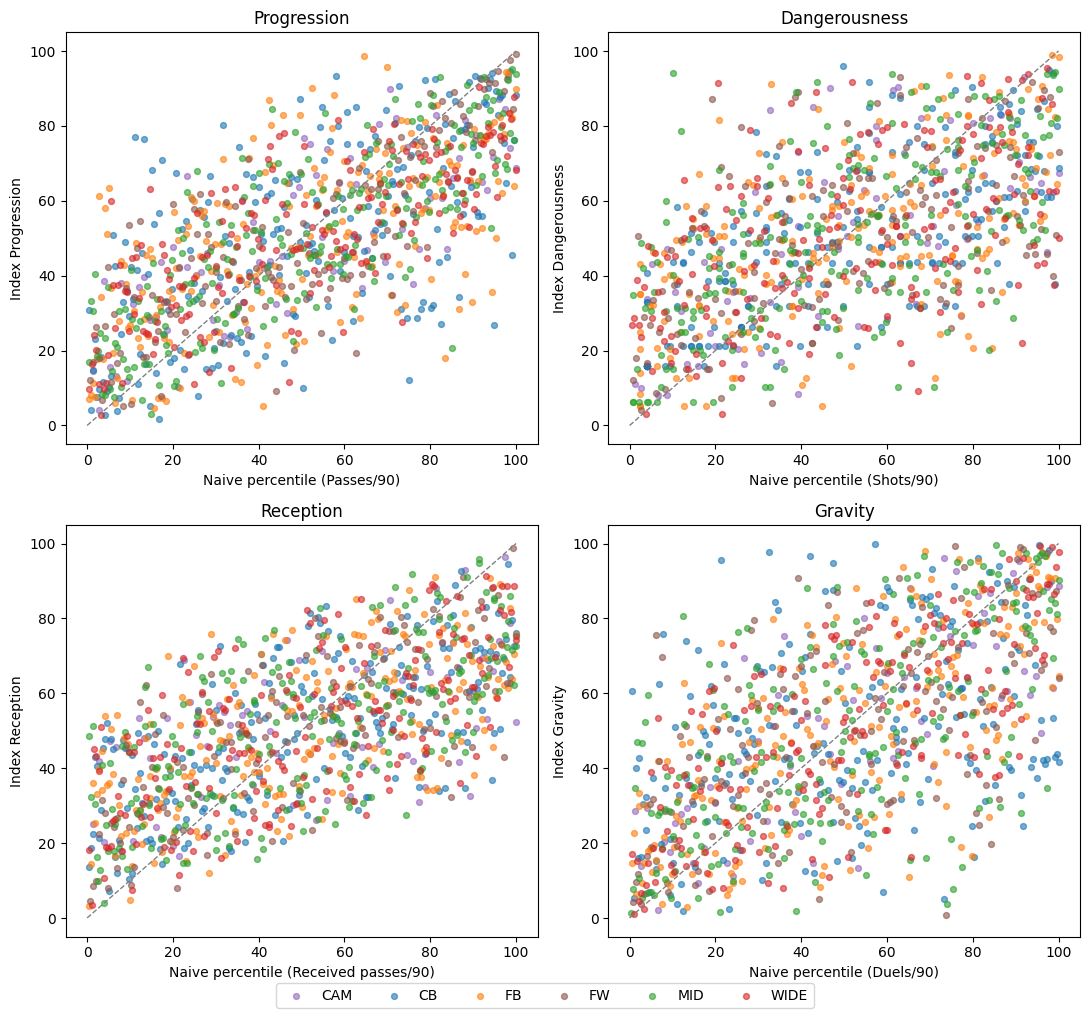

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, (name, naive_col) in zip(axes.flatten(), NAIVE_PROXY.items()):
    for role, sub in out.groupby("macro_pos"):
        ax.scatter(sub[f"pct__naive__{name}"], sub[f"idx__{name}"],
                    c=ROLE_COLORS.get(role, "grey"), s=18, alpha=0.6, label=role)
    ax.plot([0, 100], [0, 100], "--", color="grey", lw=1)
    ax.set_xlabel(f"Naive percentile ({naive_col})")
    ax.set_ylabel(f"Index {IDX_LABEL_EN[name]}")
    ax.set_title(IDX_LABEL_EN[name])
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

### 4.1 — Discoveries: Players Undervalued by Naive Metrics, Valued by Contextual Index

In [9]:
for name in IDX_COLS:
    print(f"\n=== {IDX_LABEL_EN[name]} - top 6 discoveries (positive Delta) ===")
    top = out.nlargest(6, f"delta__{name}")[["Player", "Team", "macro_pos", f"idx__{name}", f"pct__naive__{name}", f"delta__{name}"]].copy()
    top.columns = ["Player", "Team", "Role", "Index", "Naive", "Delta"]
    display(top.round(1))



=== Progression - top 6 discoveries (positive Delta) ===


,Player,Team,Role,Index,Naive,Delta
1251,Lars Hawthorne,Team 51,CB,77.0,11.1,65.9
1592,Florian Talbot,Team 37,CB,76.6,13.4,63.2
565,Alastair Arden,Team 48,FB,61.2,2.8,58.4
1304,Julian Sinclair,Team 42,FB,63.4,5.2,58.2
38,Theo Sterling,Team 39,WIDE,59.8,5.5,54.4
578,Dara Thorne,Team 48,FB,58.2,4.2,53.9



=== Dangerousness - top 6 discoveries (positive Delta) ===


,Player,Team,Role,Index,Naive,Delta
670,Roman Redmond,Team 29,MID,94.2,10.1,84.0
252,Dara Sinclair,Team 53,WIDE,91.4,20.5,70.9
691,Stefan Halloway,Team 9,FW,87.2,19.3,67.9
609,Leo Hensley,Team 27,MID,78.6,11.9,66.7
145,Lucas Pemberton,Team 33,FB,81.5,20.8,60.7
1197,Ruben Hayward,Team 12,FB,91.2,33.0,58.1



=== Reception - top 6 discoveries (positive Delta) ===


,Player,Team,Role,Index,Naive,Delta
739,Dylan Barton,Team 49,MID,67.0,14.1,52.9
412,Julian Somerset,Team 13,FB,70.0,18.9,51.1
580,Alastair Holbrook,Team 48,MID,51.2,1.3,49.9
393,Tristan Ashford,Team 24,FB,53.9,4.2,49.6
791,Simon Ellwood,Team 11,FW,62.2,13.8,48.4
405,Tristan Sinclair,Team 13,MID,61.7,13.4,48.3



=== Gravity - top 6 discoveries (positive Delta) ===


,Player,Team,Role,Index,Naive,Delta
470,Dylan Sinclair,Team 40,CB,95.6,21.2,74.4
1177,Emil Drayton,Team 12,FW,75.5,6.2,69.3
1013,Arthur Mercer,Team 32,MID,80.7,12.3,68.4
416,Julian Winslow,Team 13,CB,75.9,7.8,68.1
367,Liam Barton,Team 24,CB,97.7,32.5,65.2
1185,Stefan Fletcher,Team 12,FW,69.7,7.6,62.1


## Conclusion

- The four indices remain within the non-redundancy target (|ρ| < 0.6, Section 2), and three of them (Progression, Reception, Gravity) achieve acceptable Cronbach's Alpha (≥ 0.4) across most roles. Dangerousness, having only two underlying variables (xG90 + xA90), has a more variable alpha, typical for a 2-item index.
- Section 4 confirms the central thesis of H1 even with aggregated data: contextual indices **reorder** player rankings relative to naive volume proxies — none of the four has ρ ≈ 1, and a substantial portion of players shifts by more than 20 percentile points.
- **Gravity remains the weakest link.** It is the only index without physical geometric backing — it is inferred from fouls drawn and offensive duels rather than defensive compactness. Treat it as directional rather than a replacement for optical tracking.
- Unlike the original version, here there are no hardcoded narrative discoveries because notable names depend entirely on the loaded tournament spreadsheet — Section 4.1 generates this list dynamically on each execution.